In [1]:
# Keep the figures from changing between runs.
# Run this before any other cell so that both the seed used for sampling and
# GMM fitting and the timestamp embedded in the saved EPS / PDF stay fixed.
from pgot import set_reproducible

set_reproducible()

Generator(PCG64) at 0x7F10B9D93CA0

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ot
from sklearn.mixture import GaussianMixture as SkGaussianMixture

from lib import gromov

from pgot import (
    DEFAULT_SEED,
    GaussianMixture,
    MGW2_GM_coup,
    MGW2_coup,
    barycentric_projection,
    gaussian_cost_matrix,
    gw_mean_distortion,
    nearest_target_indices,
    pMGW2_coup,
    partial_gw_penalty,
)

In [3]:
# ---------------------------------------------------------------
# Section 7.2 geometry
#
# The paper fixes the ring radius, the sample sizes and the number of
# noise points. It leaves the target height and the noise distribution
# open, so both are pinned here and reported with the figure.
# ---------------------------------------------------------------
K = 6                 # components per ring
N = 300               # points per cloud
SIGMA = 0.2           # component standard deviation
RADIUS = 4.0          # ring radius, same for source and target
HEIGHT = 10.0         # target ring is the source ring lifted by this
N_NOISE = 10          # outlying points added to the target
NOISE_CENTER = np.array([2.5 * RADIUS, 0.0, HEIGHT])
NOISE_RADIUS = 0.3

# Separate generators per data kind: the source and the target ring must be
# independent samples, not an affine image of one another.
rng_source = np.random.default_rng(DEFAULT_SEED)
rng_target = np.random.default_rng(DEFAULT_SEED + 1)
rng_noise = np.random.default_rng(DEFAULT_SEED + 2)

theta = np.linspace(0, 2 * np.pi, K, endpoint=False)
means_source = np.stack(
    [RADIUS * np.cos(theta), RADIUS * np.sin(theta), np.zeros(K)], axis=1
)
means_target = means_source + np.array([0.0, 0.0, HEIGHT])
covariance = SIGMA**2 * np.eye(3)


def sample_ring(rng, means):
    return np.vstack(
        [rng.multivariate_normal(means[k], covariance, N // K) for k in range(K)]
    )


P1 = sample_ring(rng_source, means_source)
P2 = sample_ring(rng_target, means_target)

# Noise: uniform in a ball, a different distribution from the ring components.
direction = rng_noise.normal(size=(N_NOISE, 3))
direction /= np.linalg.norm(direction, axis=1, keepdims=True)
radius = NOISE_RADIUS * rng_noise.uniform(0, 1, N_NOISE) ** (1 / 3)
P3 = NOISE_CENTER + direction * radius[:, None]

P23 = np.vstack([P2, P3])

print(f"source P1 : {P1.shape}, ring radius {np.hypot(*P1[:, :2].T).mean():.3f}, "
      f"z = {P1[:, 2].mean():.3f} (sd {P1[:, 2].std():.3f})")
print(f"target ring: {P2.shape}, ring radius {np.hypot(*P2[:, :2].T).mean():.3f}, "
      f"z = {P2[:, 2].mean():.3f}")
print(f"target noise: {P3.shape}, centre {P3.mean(axis=0).round(3)}")
print(f"target P23 : {P23.shape}")

source P1 : (300, 3), ring radius 4.005, z = -0.010 (sd 0.191)
target ring: (300, 3), ring radius 4.007, z = 10.002
target noise: (10, 3), centre [ 9.966  0.027 10.064]
target P23 : (310, 3)


In [4]:
def set_equal_3d_axes(ax, points, margin=0.1):
    mins, maxs = points.min(axis=0), points.max(axis=0)
    centre = 0.5 * (mins + maxs)
    half = 0.5 * (maxs - mins).max() * (1 + margin)
    ax.set_xlim(centre[0] - half, centre[0] + half)
    ax.set_ylim(centre[1] - half, centre[1] + half)
    ax.set_zlim(centre[2] - half, centre[2] + half)
    ax.set_box_aspect([1, 1, 1])


ALL_POINTS = np.vstack([P1, P23])


def draw_correspondences(ax, targets, title, source_mask=None):
    """Draw both clouds and one segment per matched source point."""
    ax.scatter(*P1.T, s=30, c="blue", label="P1", alpha=0.8)
    ax.scatter(*P23.T, s=30, c="red", label="P2", alpha=0.8)
    rows = np.arange(len(P1)) if source_mask is None else np.flatnonzero(source_mask)
    for i, target in zip(rows, targets):
        ax.plot(
            [P1[i, 0], target[0]],
            [P1[i, 1], target[1]],
            [P1[i, 2], target[2]],
            c="orange",
            alpha=0.3,
            linewidth=0.8,
        )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(title)
    ax.legend()
    set_equal_3d_axes(ax, ALL_POINTS)

In [5]:
# ---------------------------------------------------------------
# One fit, one cost, shared by every mixture method
# ---------------------------------------------------------------
def fit_mixture(points, n_components, seed=DEFAULT_SEED):
    fitted = SkGaussianMixture(
        n_components=n_components, random_state=seed
    ).fit(points)
    return GaussianMixture(fitted.weights_, fitted.means_, fitted.covariances_)


mu = fit_mixture(P1, 6)
nu = fit_mixture(P23, 7)

C_mu = gaussian_cost_matrix(mu)
C_nu = gaussian_cost_matrix(nu)
component_scale = max(C_mu.max(), C_nu.max())
C_mu_n, C_nu_n = C_mu / component_scale, C_nu / component_scale

# Point-level costs, normalized by their own common maximum.
C_src = ot.dist(P1, P1)
C_tgt = ot.dist(P23, P23)
point_scale = max(C_src.max(), C_tgt.max())
C_src_n, C_tgt_n = C_src / point_scale, C_tgt / point_scale

p = ot.unif(len(P1))
q = ot.unif(len(P23))

# ---------------------------------------------------------------
# Penalty convention
#
# The two representations normalize their costs by different constants, so
# a single numeric lambda does not mean the same thing in both. We measure
# lambda in units of the mean distortion of the balanced optimum:
#
#     Lambda = lambda_tilde * gw_mean_distortion(C1, C2, G_balanced)
#
# lambda_tilde is dimensionless and shared. It is fixed so that the
# point-level penalty equals the value lambda = 0.01 reported in the paper.
# ---------------------------------------------------------------
G_gw = ot.gromov.gromov_wasserstein(C_src_n, C_tgt_n, p, q, "square_loss")
G_mgw = MGW2_GM_coup(mu, nu, C1=C_mu_n, C2=C_nu_n)

LAMBDA_PAPER = 0.01
LAMBDA_TILDE = LAMBDA_PAPER / gw_mean_distortion(C_src_n, C_tgt_n, G_gw)

lambda_point = partial_gw_penalty(LAMBDA_TILDE, C_src_n, C_tgt_n, G_gw)
lambda_component = partial_gw_penalty(LAMBDA_TILDE, C_mu_n, C_nu_n, G_mgw)

print(f"lambda_tilde        = {LAMBDA_TILDE:.4f} (dimensionless)")
print(f"  point-level  D_match = {gw_mean_distortion(C_src_n, C_tgt_n, G_gw):.6f}"
      f"  -> Lambda = {lambda_point:.6f}")
print(f"  component    D_match = {gw_mean_distortion(C_mu_n, C_nu_n, G_mgw):.6f}"
      f"  -> Lambda = {lambda_component:.6f}")

lambda_tilde        = 0.9199 (dimensionless)
  point-level  D_match = 0.010871  -> Lambda = 0.010000
  component    D_match = 0.014403  -> Lambda = 0.013249


In [6]:
# ---------------------------------------------------------------
# One solve per method. Figure 6 and Figure 7 are both read off these.
# ---------------------------------------------------------------
G_pgw = gromov.partial_gromov_ver1(
    C_src_n, C_tgt_n, p, q, Lambda=lambda_point, numItermax_gw=100
)

# Balanced couplings were already solved above for the penalty conversion.
map_gw, mask_gw = barycentric_projection(G_gw, P23)
map_pgw, mask_pgw = barycentric_projection(G_pgw, P23)

idx_mgw, map_mgw = MGW2_coup(
    P1, P23, mu=mu, nu=nu, C1=C_mu_n, C2=C_nu_n,
    method="T_mean", return_both=True,
)
idx_pmgw, map_pmgw = pMGW2_coup(
    P1, P23, Lambda=lambda_component,
    n_components_X=6, n_components_Y=7,
    mu=mu, nu=nu, C1=C_mu, C2=C_nu,
    solver_tol=1e-12, return_both=True, verbose=True,
)

idx_gw = nearest_target_indices(map_gw, P23)
idx_pgw = nearest_target_indices(map_pgw, P23)

structured = np.arange(len(P23)) < len(P2)
for name, mass, idx, mask in [
    ("GW2", G_gw.sum(), idx_gw, mask_gw),
    ("PGW2", G_pgw.sum(), idx_pgw, mask_pgw),
    ("MGW2", 1.0, idx_mgw, np.ones(len(P1), bool)),
    ("pMGW2", None, idx_pmgw, np.ones(len(P1), bool)),  # mass printed above
]:
    onto_noise = int((~structured[idx]).sum())
    mass_text = "-" if mass is None else f"{mass:.7f}"
    print(f"{name:<6} matched mass {mass_text:>10}  "
          f"source points drawn {int(mask.sum()):>3}/{len(P1)}  "
          f"landing on noise {onto_noise:>3}")
print(f"\n300/310 = {300 / 310:.7f}")

Deriving partial MGW coupling with Lambda=0.013249170800775967
It.  |Err         |Loss        
-------------------------------
    0|2.086409e-01|1.285542e-38
Calculation time: 0.001280 sec
Total matched mass Z_lambda = 0.967742
GW2    matched mass  1.0000000  source points drawn 300/300  landing on noise  10
PGW2   matched mass  0.9677419  source points drawn 294/300  landing on noise   0
MGW2   matched mass  1.0000000  source points drawn 300/300  landing on noise   0
pMGW2  matched mass          -  source points drawn 300/300  landing on noise   0

300/310 = 0.9677419


/home/yukimura/EPGOT-PMGW/.venv/lib/python3.13/site-packages/lib/gromov.py:790: UserWarning: This function will be deprecated in a near future, please use ot.gromov.gwloss` instead.
  print("{:5d}|{:8e}|{:8e}".format(cpt, err, gwloss_partial(C1, C2, G0)))
/home/yukimura/EPGOT-PMGW/.venv/lib/python3.13/site-packages/ot/partial/partial_solvers.py:887: UserWarning: This function will be deprecated in a near future, please use ot.gromov.gwggrad` instead.
  g = gwgrad_partial(C1, C2, T) * 0.5


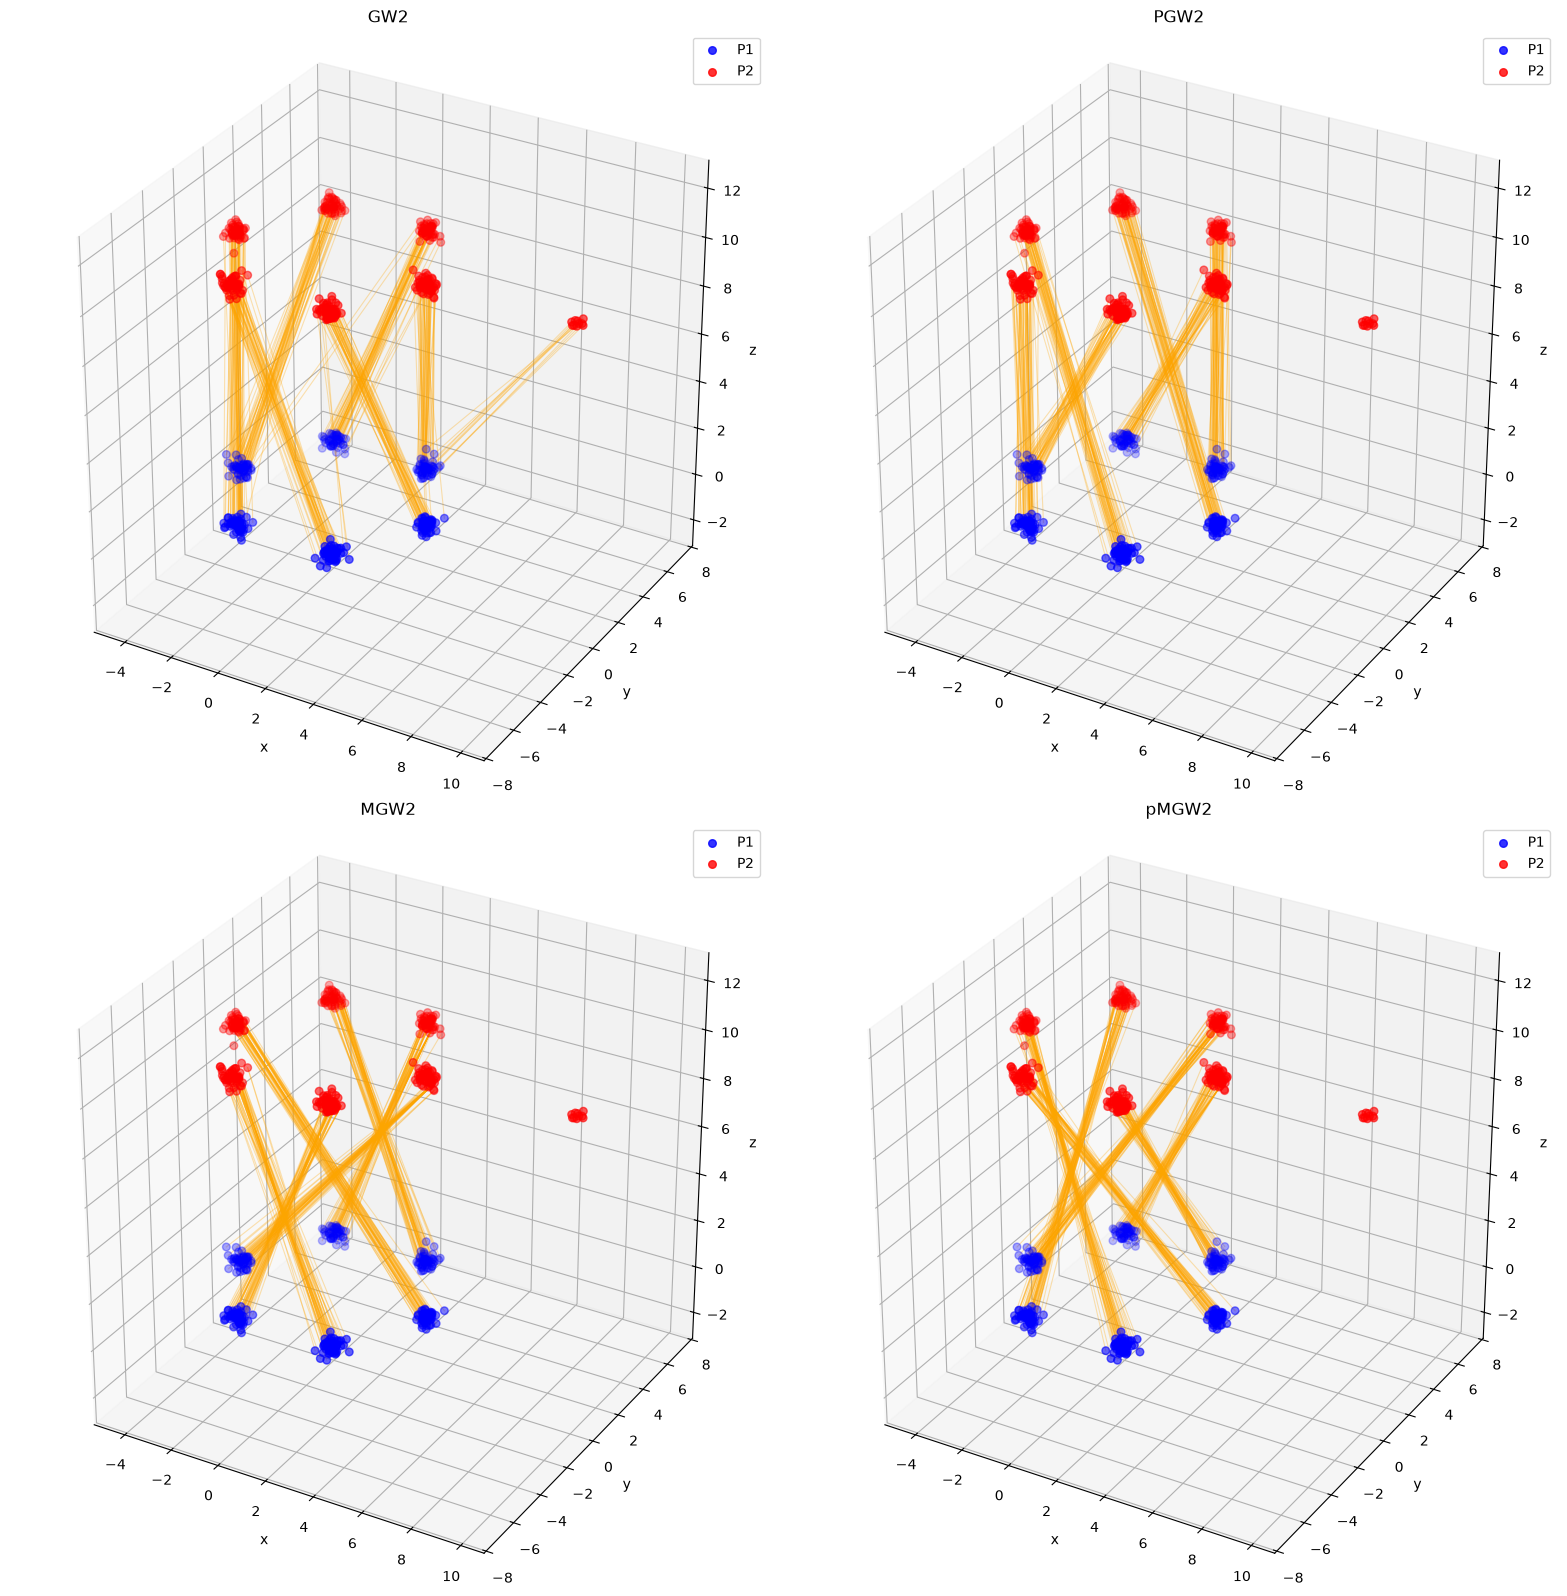

In [7]:
# Figure 6: nearest-point correspondences from the barycentric projections
fig, axes = plt.subplots(2, 2, figsize=(16, 16), subplot_kw={"projection": "3d"})
draw_correspondences(axes[0, 0], P23[idx_gw], "GW2", mask_gw)
draw_correspondences(axes[0, 1], P23[idx_pgw], "PGW2", mask_pgw)
draw_correspondences(axes[1, 0], P23[idx_mgw], "MGW2")
draw_correspondences(axes[1, 1], P23[idx_pmgw], "pMGW2")
plt.tight_layout()
plt.savefig("figure6_nearest_point.pdf", format="pdf", bbox_inches="tight")
plt.show()

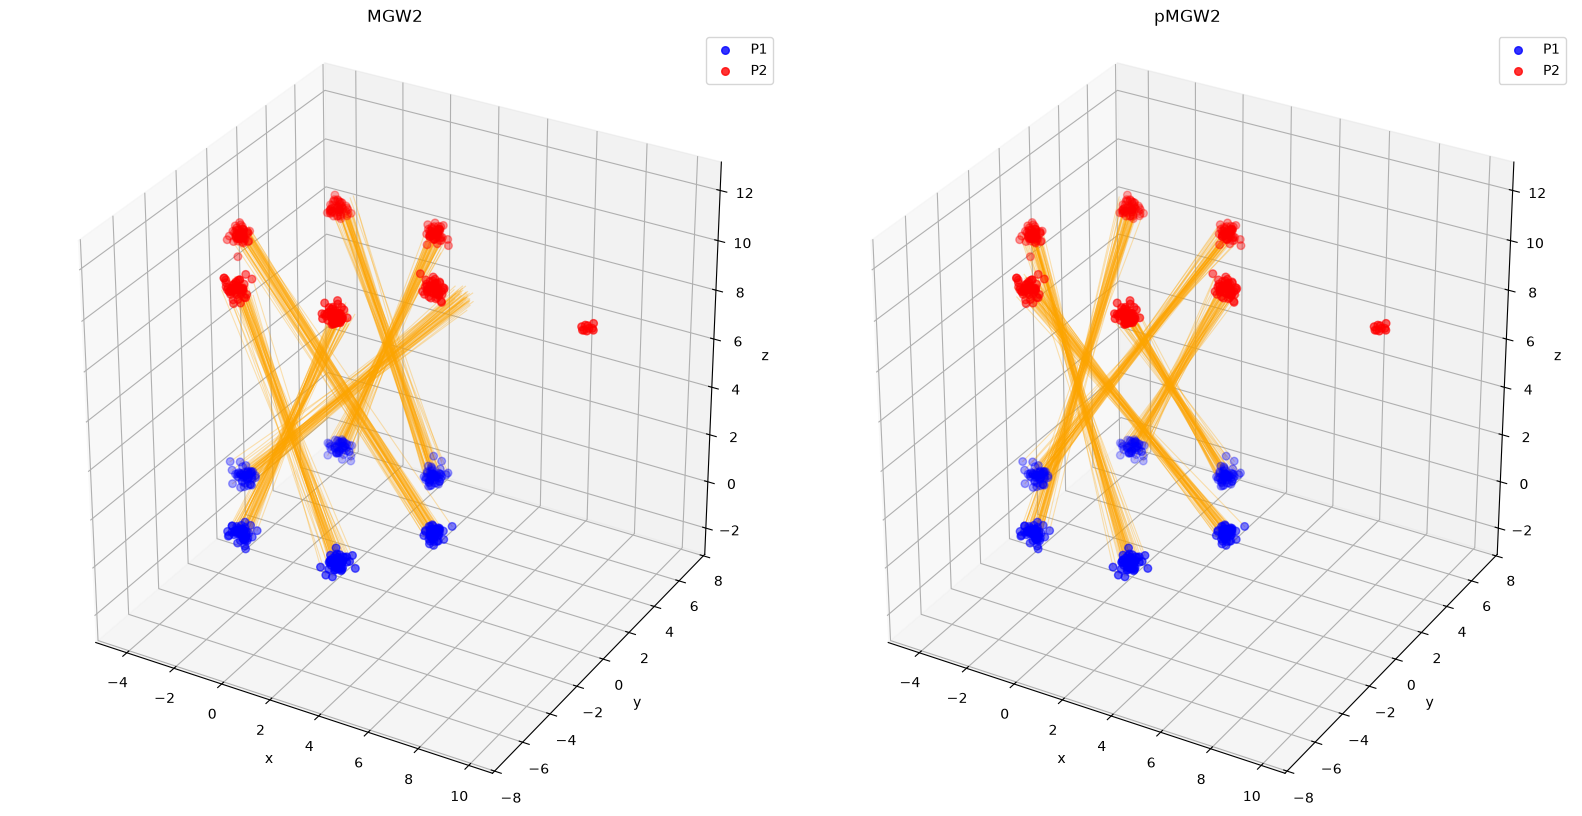

In [8]:
# Figure 7: the same maps before the nearest-point assignment
fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={"projection": "3d"})
draw_correspondences(axes[0], map_mgw, "MGW2")
draw_correspondences(axes[1], map_pmgw, "pMGW2")
plt.tight_layout()
plt.savefig("figure7_barycentric.pdf", format="pdf", bbox_inches="tight")
plt.show()